<a href="https://colab.research.google.com/github/jcmachicao/cur_MMAI__multimodal/blob/main/cMMAI___ideas_iniciales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Introducción a la IA Generativa Multimodal

La Inteligencia Artificial Multimodal se refiere a sistemas de IA que pueden procesar y/o generar información utilizando múltiples modalidades de datos, como texto, imágenes, audio y video. Esto les permite comprender el mundo de una manera más holística y natural, similar a cómo lo hacen los humanos. Los algoritmos multimodales son fundamentales para muchas aplicaciones avanzadas, desde la descripción de imágenes hasta la traducción de audio a texto y la creación de contenido multimedia.

Aquí exploraremos algunos ejemplos clave de algoritmos multimodales que demuestran la diversidad de interacciones entre diferentes tipos de datos.

### 1. Whisper: Reconocimiento de Voz Multimodal (Audio a Texto)

**Whisper** es un modelo de reconocimiento automático de voz (ASR) desarrollado por OpenAI. Es un excelente ejemplo de un algoritmo multimodal que toma **audio** como entrada y lo transcribe a **texto**. Su robustez se debe a que fue entrenado con una gran cantidad de datos de audio supervisados en varios idiomas, lo que lo hace muy competente en la transcripción de voz, incluso en entornos ruidosos o con diferentes acentos.

In [1]:
# Instalar la librería transformers si aún no está instalada
!pip install -qqq transformers datasets soundfile accelerate

In [2]:
import torch
from transformers import pipeline
import datasets

In [ ]:
# Descargar un dataset de audio de ejemplo (por ejemplo, de LibriSpeech)
# Usaremos un pequeño clip de audio para demostración.
# Si no tienes un archivo de audio local, puedes descargarlo o usar uno de Hugging Face Datasets.

In [ ]:
# Opcion 1: Usar un archivo local (si tienes uno)
audio_file = "./your_audio_file.flac"

In [ ]:
# Opcion 2: Descargar un clip de audio de ejemplo
# Puedes buscar "audio sample" en Google o usar un clip de Hugging Face
# Aquí un ejemplo simple (necesitarías descargar un archivo .flac o .wav)
# Para un ejemplo rápido, vamos a crear un pequeño archivo de audio sintético o descargar uno trivial.

# Para simplificar y no depender de descargas externas directas a Colab,
# usaremos el dataset 'librispeech_asr' y tomaremos un ejemplo.
url = "/home/albert/.cache/huggingface/datasets/downloads/extracted/4a12a5d9e3d43248af424bf5fb40094f2aac834e9c19b34fb91aa912db1bd0b0/6930-75918-0000.flac"
# Cargar un dataset de ejemplo con audio
dataset = datasets.load_dataset("librispeech_asr", "clean", split="test", streaming=True)
# Tomar el primer ejemplo del dataset
sample = next(iter(dataset))
audio_path = sample["file"]

In [ ]:
sample

In [5]:
print(f"Ruta del archivo de audio de ejemplo: {audio_path}")

# Inicializar el pipeline de transcripción de Whisper
transcriber = pipeline("automatic-speech-recognition", model="openai/whisper-tiny.en", device=0 if torch.cuda.is_available() else -1)

# Transcribir el audio
result = transcriber(audio_path)

print("\nTranscripción de Whisper:")
print(result["text"])

Resolving data files:   0%|          | 0/48 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/48 [00:00<?, ?it/s]

Ruta del archivo de audio de ejemplo: /home/albert/.cache/huggingface/datasets/downloads/extracted/4a12a5d9e3d43248af424bf5fb40094f2aac834e9c19b34fb91aa912db1bd0b0/6930-75918-0000.flac


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/151M [00:00<?, ?B/s]

...

normalizer.json: 0.00B [00:00, ?B/s]

added_tokens.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

preprocessor_config.json: 0.00B [00:00, ?B/s]

FileNotFoundError: [Errno 2] No such file or directory: '/home/albert/.cache/huggingface/datasets/downloads/extracted/4a12a5d9e3d43248af424bf5fb40094f2aac834e9c19b34fb91aa912db1bd0b0/6930-75918-0000.flac'

### 2. Image Captioning: Descripción de Imágenes (Visión a Texto)

**Image Captioning** es la tarea de generar una descripción textual para una imagen dada. Este es un ejemplo clásico de multimodalidad donde la entrada es una **imagen** y la salida es **texto**. Los modelos modernos utilizan una combinación de redes neuronales convolucionales (CNN) para extraer características visuales de la imagen y redes recurrentes (RNN) o Transformers para generar la secuencia de palabras.

In [6]:
# Instalar la librería Pillow para manejo de imágenes
!pip install -qqq Pillow

Imagen de ejemplo:


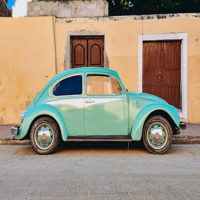

preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

The image processor of type `BlipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/990M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie text_decoder.cls.predictions.bias to text_decoder.cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForConditionalGeneration LOAD REPORT from: Salesforce/blip-image-captioning-base
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identic


Descripción de la imagen:
a green volkswagen beetle parked in front of a yellow building


In [8]:
from transformers import BlipProcessor, BlipForConditionalGeneration
from PIL import Image
import requests
from io import BytesIO
import torch # Import torch explicitly

# Cargar una imagen de ejemplo desde una URL
url = "https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/transformers/tasks/car.jpg"
response = requests.get(url)
image = Image.open(BytesIO(response.content))

print("Imagen de ejemplo:")
display(image.resize((200, 200))) # Mostrar una versión más pequeña de la imagen

# Cargar el procesador y el modelo de BLIP para generación de subtítulos
processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base")

# Mover el modelo a la GPU si está disponible
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

# Procesar la imagen y generar la descripción
inputs = processor(image, return_tensors="pt").to(device)
out = model.generate(**inputs)
caption = processor.decode(out[0], skip_special_tokens=True)

print("\nDescripción de la imagen:")
print(caption)

### 3. Text-to-Image Generation: Creación de Imágenes a partir de Texto (Texto a Visión Generativa)

La **generación de imágenes a partir de texto** es quizás el ejemplo más impactante de IA generativa multimodal. Modelos como DALL-E, Stable Diffusion o Midjourney toman una descripción en **texto** (un "prompt") y generan una **imagen** completamente nueva que se ajusta a esa descripción. Esto demuestra la capacidad de la IA para traducir conceptos abstractos y lingüísticos en contenido visual concreto.

In [9]:
# Instalar la librería diffusers para modelos de difusión
!pip install -qqq diffusers

In [ ]:
from diffusers import StableDiffusionPipeline
import torch

# Cargar un modelo de Stable Diffusion (puede tardar un poco la primera vez)
# Usaremos un modelo pequeño para una demostración más rápida, como 'stabilityai/stable-diffusion-v1-4'
# Para modelos más avanzados, considera 'runwayml/stable-diffusion-v1-5' o versiones posteriores.

# Asegurarse de tener suficiente RAM en Colab para el modelo, 'fp16' ayuda a reducir el uso de memoria.
# Si no tienes GPU, device='cpu' es necesario y será más lento.

pipeline = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch.float16,
    use_safetensors=True
)

pipeline.to("cuda" if torch.cuda.is_available() else "cpu")

# Definir el prompt de texto para la generación de la imagen
prompt = "a photo of an astronaut riding a horse on mars, high resolution, detailed, cinematic lighting"

# Generar la imagen
# num_inference_steps más bajos (e.g., 20) para resultados más rápidos, pero de menor calidad.
# num_inference_steps más altos (e.g., 50) para mejor calidad, pero más lentos.
image = pipeline(prompt, num_inference_steps=25).images[0]

print("Prompt de texto:")
print(prompt)

print("\nImagen generada:")
display(image)

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Pipelines loaded with `dtype=torch.float16` cannot run with `cpu` device. It is not recommended to move them to `cpu` as running them will fail. Please make sure to use an accelerator to run the pipeline in inference, due to the lack of support for`float16` operations on this device in PyTorch. Please, remove the `torch_dtype=torch.float16` argument, or use another device for inference.
Pipelines loaded with `dtype=torch.float16` cannot run with `cpu` device. It is not recommended to m

  0%|          | 0/25 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/diffusers/configuration_utils.py:173: FutureWarning: Accessing config attribute `__iter__` directly via 'StableDiffusionPipeline' object attribute is deprecated. Please access '__iter__' over 'StableDiffusionPipeline's config object instead, e.g. 'scheduler.config.__iter__'.
  deprecate("direct config name access", "1.0.0", deprecation_message, standard_warn=False)
/usr/local/lib/python3.12/dist-packages/diffusers/configuration_utils.py:173: FutureWarning: Accessing config attribute `__iter__` directly via 'StableDiffusionPipeline' object attribute is deprecated. Please access '__iter__' over 'StableDiffusionPipeline's config object instead, e.g. 'scheduler.config.__iter__'.
  deprecate("direct config name access", "1.0.0", deprecation_message, standard_warn=False)


Estos ejemplos demuestran cómo los algoritmos multimodales pueden interactuar con diferentes tipos de datos, desde la comprensión del habla hasta la descripción de imágenes y la creación de arte visual a partir de texto. Son la base de muchas de las capacidades más emocionantes de la IA generativa actual.